In [1]:
import pandas as pd
import os
import seaborn as sns
import numpy as np

In [2]:
id_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/identity/zebrafish/single_condition_identity_from_same_timepoint"
cf_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/zebrafish/single_condition_f"
tp_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/identity/zebrafish/single_condition_displacement_vector_same_timepoint"
pert_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/identity/zebrafish/single_condition_displacement_vector_same_perturbation"
cl_emb_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/identity/zebrafish/single_condition_closest_embedding"

In [3]:
out_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/zebrafish_new/results/allocation"

In [4]:
ood_conditions = ['zc4h2_control_24','met_control_36','tfap2a_control_72','hgfa_control_48','tfap2a_foxd3_72','noto_control_18','cdx4_cdx1a_36','epha4a_control_48','mafba_control_36','tbx16_msgn1_24','noto_control_24','smo_control_18','hand2_control_24','noto_control_36','egr2b_control_36','cdx4_control_18','tfap2a_control_36','foxi1_control_72','egr2b_control_24','cdx4_control_36','zc4h2_control_36','hoxb1a_control_48','tfap2a_foxd3_36','tbx16_tbx16l_24','smo_control_36','mafba_control_18','hgfa_control_72','tbx16_control_18','mafba_control_24','tbx1_control_36','zc4h2_control_48','wnt3a_wnt8_36','foxi1_control_48','smo_control_24','noto_control_48','mafba_control_48','tfap2a_control_48','hand2_control_48','egr2b_control_48','phox2a_control_48','tbx1_control_48','tbx16_msgn1_36','foxd3_control_72','wnt3a_wnt8_24','egr2b_control_18','wnt3a_wnt8_18','met_control_72','phox2a_control_36','epha4a_control_24','foxd3_control_36','tfap2a_foxd3_48','hand2_control_36','cdx4_cdx1a_24','hgfa_control_36','tbx16_tbx16l_18','tbxta_control_36','cdx4_control_24','foxd3_control_48','met_control_48','tbx1_control_24','epha4a_control_36','cdx4_cdx1a_18','tbx16_control_36','tbx16_tbx16l_36','tbx16_control_24','tbxta_control_24','tbx16_msgn1_18','epha4a_control_18','tbxta_control_18','hoxb1a_control_36','hoxb1a_control_24']
      

In [5]:
dfs = []
for ood_cond in ood_conditions:
    csv_file = [el for el in os.listdir(cf_dir) if ((ood_cond in el) and ("csv" in el))]
    if len(csv_file)==0:
        continue
    assert len(csv_file) == 1
    df = pd.read_csv(os.path.join(cf_dir, csv_file[0])).set_index("Unnamed: 0").T
    df["condition"] = f"{ood_cond}"
    dfs.append(df)

In [6]:
df_cf = pd.concat(dfs)

In [7]:
dfs = []
for ood_cond in ood_conditions:
    csv_file = [el for el in os.listdir(id_dir) if ((ood_cond in el) and ("csv" in el))]
    assert len(csv_file) == 1
    df = pd.read_csv(os.path.join(id_dir, csv_file[0])).set_index("Unnamed: 0").T
    df["condition"] = f"{ood_cond}"
    dfs.append(df)

In [8]:
df_id = pd.concat(dfs)

In [9]:
dfs = []
for ood_cond in ood_conditions:
    csv_file = [el for el in os.listdir(tp_dir) if ((ood_cond in el) and ("csv" in el))]
    assert len(csv_file) == 1
    df = pd.read_csv(os.path.join(tp_dir, csv_file[0])).set_index("Unnamed: 0").T
    df["condition"] = f"{ood_cond}"
    dfs.append(df)

In [10]:
df_tp = pd.concat(dfs)

In [11]:
dfs = []
for ood_cond in ood_conditions:
    csv_file = [el for el in os.listdir(pert_dir) if ((ood_cond in el) and ("csv" in el))]
    assert len(csv_file) == 1
    df = pd.read_csv(os.path.join(pert_dir, csv_file[0])).set_index("Unnamed: 0").T
    df["condition"] = f"{ood_cond}"
    dfs.append(df)

In [12]:
df_pert = pd.concat(dfs)

In [13]:
dfs = []
for ood_cond in ood_conditions:
    csv_file = [el for el in os.listdir(cl_emb_dir) if ((ood_cond in el) and ("csv" in el))]
    assert len(csv_file) == 1
    df = pd.read_csv(os.path.join(cl_emb_dir, csv_file[0])).set_index("Unnamed: 0").T
    df["condition"] = f"{ood_cond}"
    dfs.append(df)

In [14]:
df_cl_emb = pd.concat(dfs)

In [15]:
len(df_id), len(df_cf), len(df_cf), len(df_pert), len(df_cl_emb)

(71, 71, 71, 71, 71)

In [16]:
df_id["model"]="id"
df_cf["model"]="cf"
df_tp["model"]="same_timepoint"
df_pert["model"]="same_perturbation"
df_cl_emb["model"]="closest_embedding"

/tmp/ipykernel_1094459/585828636.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_id["model"]="id"
/tmp/ipykernel_1094459/585828636.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cf["model"]="cf"
/tmp/ipykernel_1094459/585828636.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tp[

In [17]:
df_all = pd.concat((df_id, df_cf, df_tp, df_pert, df_cl_emb))

In [18]:
df_all.to_csv(os.path.join(out_dir, "all_models_metrics.csv"))

<Axes: xlabel='model', ylabel='ood_e_distance'>

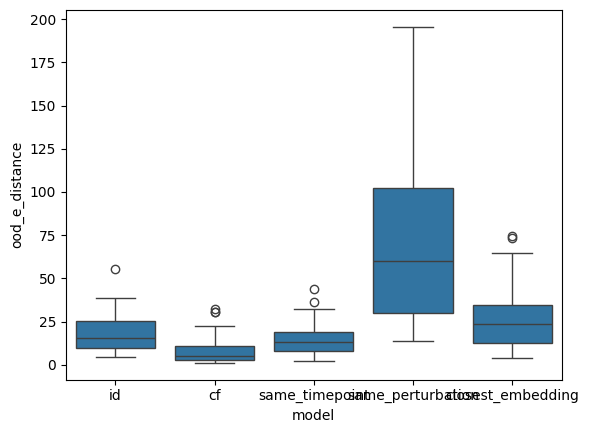

In [19]:
sns.boxplot(df_all, x="model", y="ood_e_distance")

<Axes: xlabel='model', ylabel='cell_type_fraction_error'>

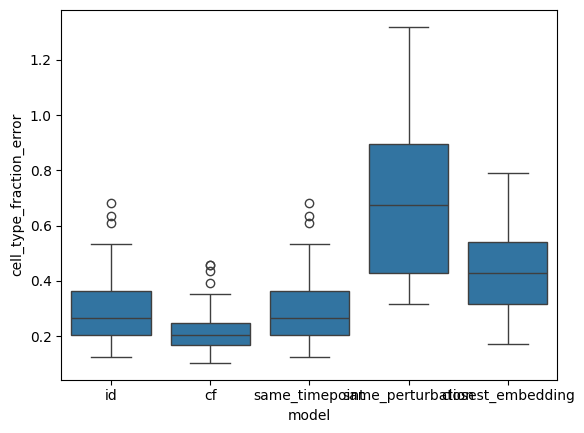

In [20]:
sns.boxplot(df_all, x="model", y="cell_type_fraction_error")

<Axes: xlabel='model', ylabel='fraction_cell_types_covered'>

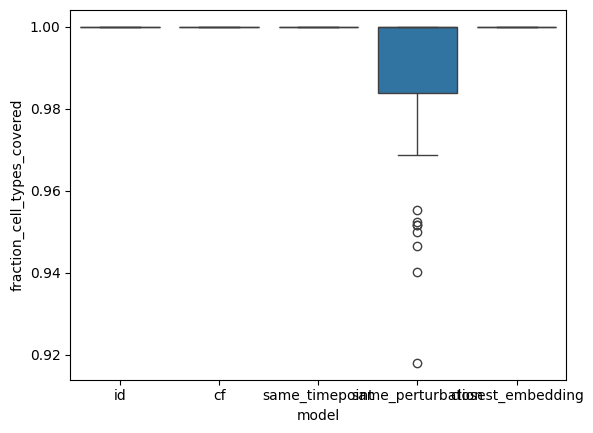

In [21]:
sns.boxplot(df_all, x="model", y="fraction_cell_types_covered")

<Axes: xlabel='model', ylabel='mean_e_distance_per_cell_type'>

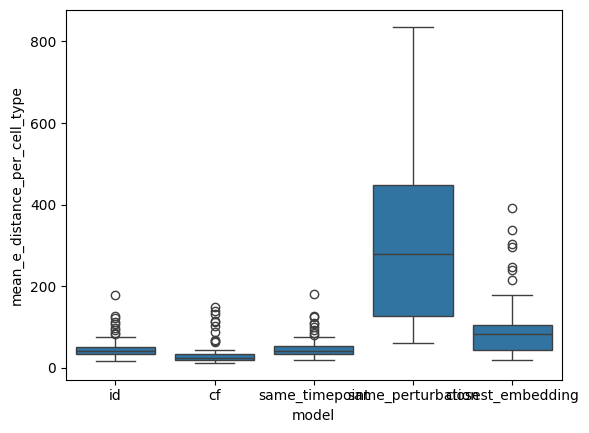

In [22]:
sns.boxplot(df_all, x="model", y="mean_e_distance_per_cell_type")

In [23]:
df_all.head()

Unnamed: 0,fraction_cell_types_covered,cell_type_fraction_error,mean_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,median_r_sq_per_cell_type,median_e_distance_per_cell_type,median_mmd_per_cell_type,...,e_distance_hypochord,mmd_hypochord,div_10_hypochord,div_100_hypochord,r_squared_hypophysis/locus coeruleus,e_distance_hypophysis/locus coeruleus,mmd_hypophysis/locus coeruleus,div_10_hypophysis/locus coeruleus,div_100_hypophysis/locus coeruleus,model
zc4h2_control_24,1.0,0.198075,0.997143,17.884346,0.007304,176.589351,50.130940,0.998086,10.724632,0.006735,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,id
met_control_36,1.0,0.290707,0.996653,21.373934,0.007520,196.086758,64.315720,0.997639,15.631581,0.006816,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,id
tfap2a_control_72,1.0,0.321600,0.979980,127.018322,0.009210,338.764505,212.046395,0.996153,24.456763,0.007337,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,id
hgfa_control_48,1.0,0.348580,0.990385,55.715163,0.012429,239.495950,99.938459,0.993441,34.930590,0.011155,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,id
tfap2a_foxd3_72,1.0,0.229467,0.988895,92.352286,0.009099,292.229661,157.077969,0.994277,32.852069,0.007775,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,id


In [25]:
# check best model
df_id["ood_e_distance"].mean(), df_tp["ood_e_distance"].mean(), df_pert["ood_e_distance"].mean(), df_cf["ood_e_distance"].mean(), df_cl_emb["ood_e_distance"].mean()

(17.762491450561733,
 14.737535430913129,
 69.86388937501904,
 7.492472049472113,
 26.45060194291341)

# Create MMD based difference

In [26]:
def larger_zero(x):
    if x["value"]>0:
        return "True"
    if x["value"]<0:
        return "False"
    return None


In [27]:
df_id_mmd = df_id[[el for el in df_id.columns if el.startswith("mmd")]]
df_tp_mmd = df_tp[[el for el in df_tp.columns if el.startswith("mmd")]]
df_cf_mmd = df_cf[[el for el in df_cf.columns if el.startswith("mmd")]]

df_diff_mmd = df_tp_mmd - df_cf_mmd
df_diff_mmd["condition"] = df_diff_mmd.index

df_diff_mmd = pd.melt(df_diff_mmd, id_vars=["condition"], value_vars=None)

df_id_mmd["condition"] = df_id_mmd.index
df_id_mmd = pd.melt(df_id_mmd, id_vars=["condition"], value_vars=None)

df_id_mmd["perturbation_effect"] = df_id_mmd["value"]
df_id_mmd=df_id_mmd.drop(columns=["value"])

df_merged = pd.merge(df_diff_mmd, df_id_mmd, left_on=["condition", "Unnamed: 0"], right_on=["condition", "Unnamed: 0"], suffixes=(None, None))
df_merged["cell_type"] = df_merged.apply(lambda x: "_".join(x["Unnamed: 0"].split("_")[1:]), axis=1)
df_merged["log_value"] = df_merged.apply(lambda x: np.sign(x["value"]) * np.log(np.abs(x["value"])), axis=1)
df_merged["larger_zero"] = df_merged.apply(larger_zero, axis=1)
df_merged["log_perturbation_effect"] = df_merged.apply(lambda x: None if x["perturbation_effect"] is None else np.log(x["perturbation_effect"] +1.0), axis=1) 
df_merged["cell_type"] = df_merged.apply(lambda x: "_".join(x["cell_type"].split("_")[0:]), axis=1)

df_merged.to_csv(os.path.join(out_dir, "same_tp_cf_diff_mmd.csv"))


/tmp/ipykernel_1094459/3973310602.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_id_mmd["condition"] = df_id_mmd.index


# Create Sink div based difference

In [28]:
df_id_sink_div = df_id[[el for el in df_id.columns if el.startswith("div_100")]]
df_tp_sink_div = df_tp[[el for el in df_tp.columns if el.startswith("div_100")]]
df_cf_sink_div = df_cf[[el for el in df_cf.columns if el.startswith("div_100")]]

df_diff_sink_div = df_tp_sink_div - df_cf_sink_div
df_diff_sink_div["condition"] = df_diff_sink_div.index

df_diff_sink_div = pd.melt(df_diff_sink_div, id_vars=["condition"], value_vars=None)

df_id_sink_div["condition"] = df_id_sink_div.index
df_id_sink_div = pd.melt(df_id_sink_div, id_vars=["condition"], value_vars=None)

df_id_sink_div["perturbation_effect"] = df_id_sink_div["value"]
df_id_sink_div=df_id_sink_div.drop(columns=["value"])

df_merged = pd.merge(df_diff_sink_div, df_id_sink_div, left_on=["condition", "Unnamed: 0"], right_on=["condition", "Unnamed: 0"], suffixes=(None, None))
df_merged["cell_type"] = df_merged.apply(lambda x: "_".join(x["Unnamed: 0"].split("_")[1:]), axis=1)
df_merged["log_value"] = df_merged.apply(lambda x: np.sign(x["value"]) * np.log(np.abs(x["value"])), axis=1)
df_merged["larger_zero"] = df_merged.apply(larger_zero, axis=1)
df_merged["log_perturbation_effect"] = df_merged.apply(lambda x: None if x["perturbation_effect"] is None else np.log(x["perturbation_effect"] +1.0), axis=1) 
df_merged["cell_type"] = df_merged.apply(lambda x: "_".join(x["cell_type"].split("_")[1:]), axis=1)
df_merged.to_csv(os.path.join(out_dir, "same_tp_cf_diff_sink_div.csv"))

/tmp/ipykernel_1094459/3683279775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_id_sink_div["condition"] = df_id_sink_div.index


# Create E distance based difference

In [29]:
df_id_e_dist = df_id[[el for el in df_id.columns if el.startswith("e_distance")]]
df_tp_e_dist = df_tp[[el for el in df_tp.columns if el.startswith("e_distance")]]
df_cf_e_dist = df_cf[[el for el in df_cf.columns if el.startswith("e_distance")]]

df_diff_e_dist = df_tp_e_dist - df_cf_e_dist
df_diff_e_dist["condition"] = df_diff_e_dist.index

df_diff_e_dist = pd.melt(df_diff_e_dist, id_vars=["condition"], value_vars=None)

df_id_e_dist["condition"] = df_id_e_dist.index
df_id_e_dist = pd.melt(df_id_e_dist, id_vars=["condition"], value_vars=None)

df_id_e_dist["perturbation_effect"] = df_id_e_dist["value"]
df_id_e_dist=df_id_e_dist.drop(columns=["value"])

df_merged = pd.merge(df_diff_e_dist, df_id_e_dist, left_on=["condition", "Unnamed: 0"], right_on=["condition", "Unnamed: 0"], suffixes=(None, None))
df_merged["cell_type"] = df_merged.apply(lambda x: "_".join(x["Unnamed: 0"].split("_")[1:]), axis=1)
df_merged["log_value"] = df_merged.apply(lambda x: np.sign(x["value"]) * np.log(np.abs(x["value"])), axis=1)
df_merged["larger_zero"] = df_merged.apply(larger_zero, axis=1)
df_merged["log_perturbation_effect"] = df_merged.apply(lambda x: None if x["perturbation_effect"] is None else np.log(x["perturbation_effect"] +1.0), axis=1) 
df_merged["cell_type"] = df_merged.apply(lambda x: "_".join(x["cell_type"].split("_")[1:]), axis=1)
df_merged.to_csv(os.path.join(out_dir, "same_tp_cf_diff_e_distance.csv"))

/tmp/ipykernel_1094459/2101860551.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_id_e_dist["condition"] = df_id_e_dist.index


In [30]:
# this is for log-fold changes
df_id_e_dist = np.log2(df_id[[el for el in df_id.columns if el.startswith("e_distance")]])
df_tp_e_dist = np.log2(df_tp[[el for el in df_tp.columns if el.startswith("e_distance")]])
df_cf_e_dist = np.log2(df_cf[[el for el in df_cf.columns if el.startswith("e_distance")]])

df_diff_e_dist = df_tp_e_dist - df_cf_e_dist
df_diff_e_dist["condition"] = df_diff_e_dist.index

df_diff_e_dist = pd.melt(df_diff_e_dist, id_vars=["condition"], value_vars=None)

df_id_e_dist["condition"] = df_id_e_dist.index
df_id_e_dist = pd.melt(df_id_e_dist, id_vars=["condition"], value_vars=None)

df_id_e_dist["perturbation_effect"] = df_id_e_dist["value"]
df_id_e_dist=df_id_e_dist.drop(columns=["value"])

df_id_e_dist= df_id_e_dist.rename(columns={"Unnamed: 0": "variable"})
df_diff_e_dist=df_diff_e_dist.rename(columns={"Unnamed: 0": "variable"})
df_merged = pd.merge(df_diff_e_dist, df_id_e_dist, left_on=["condition", "variable"], right_on=["condition", "variable"], suffixes=(None, None))
df_merged["cell_type"] = df_merged.apply(lambda x: "_".join(x["variable"].split("_")[1:]), axis=1)

df_merged["timepoint"] = df_merged.apply(lambda x: x["condition"].split("_")[-1], axis=1)
df_merged["gene_target"] = df_merged.apply(lambda x: "_".join(x["condition"].split("_")[:-1]), axis=1)
df_merged.to_csv(os.path.join(out_dir, "same_tp_cf_diff_e_distance_logfoldchanges.csv"))